In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
data = pd.read_csv('mlr1.csv')  # Adjust the path if necessary

In [17]:
# One-hot encode the 'x3' column
data = pd.get_dummies(data, columns=['x3'])

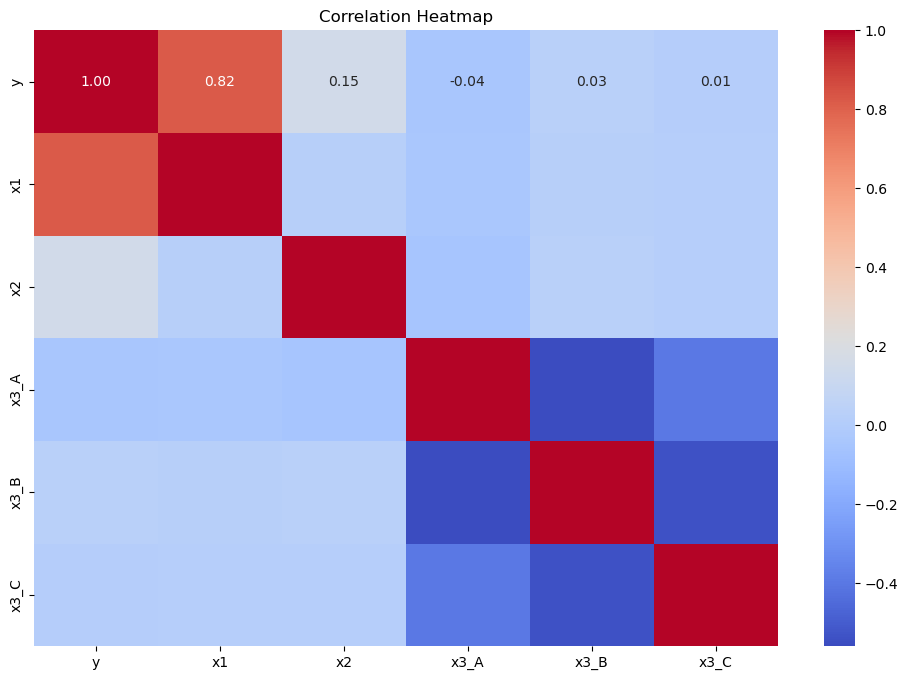

In [19]:
# Calculate the correlation matrix
correlation_matrix = data.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [21]:
# Define features (X) and target variable (y)
X = data.drop(columns=['y'])  # Features (all columns except the target)
y = data['y']                 # Target variable

In [23]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23286091)

In [25]:
# Initialize the model
model = LinearRegression()

# Fit the model on the training data
model.fit(X_train, y_train)

LinearRegression()

In [27]:
# Print model coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [291.77500074  60.67879323 -31.75978189  43.41552477 -11.65574288]
Intercept: -11263.041775188447


In [29]:
# Predict on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')

Mean Squared Error: 1550783.8105903515
R² Score: 0.691041775497446


In [37]:
#Time Series

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load the dataset
data = pd.read_csv('ts1.csv')  # Adjust path if needed

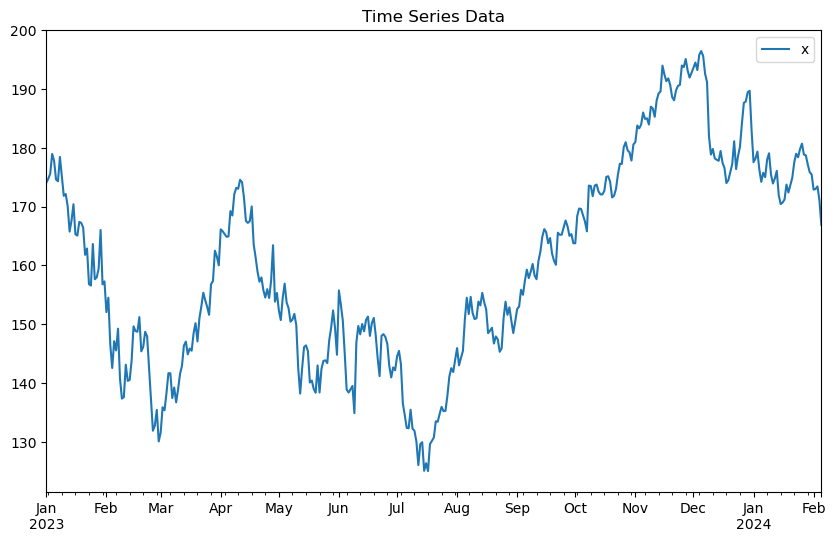

In [73]:
# Step 2: Inspect and Preprocess the Data

# Reset the index to create a sequential date index starting from '2023-01-01'
data.index = pd.date_range(start='2023-01-01', periods=len(data), freq='D')

# Display the first few rows to confirm the structure
data.head()

# Plot the time series to understand its trend
data.plot(figsize=(10, 6))
plt.title('Time Series Data')
plt.show()


In [75]:
# Step 3: Split the Data into Training and Testing Sets

# Determine the split point
split_point = int(len(data) * 0.8)

# Split the dataset
train, test = data.iloc[:split_point], data.iloc[split_point:]

In [77]:
# Step 4: Fit a Time Series Model

# Initialize and fit the Exponential Smoothing model
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Apply the model on the training set
model = ExponentialSmoothing(train['x'], trend="add", seasonal="add", seasonal_periods=12)
model_fit = model.fit()

# Forecast for the length of the test set
forecast = model_fit.forecast(len(test))

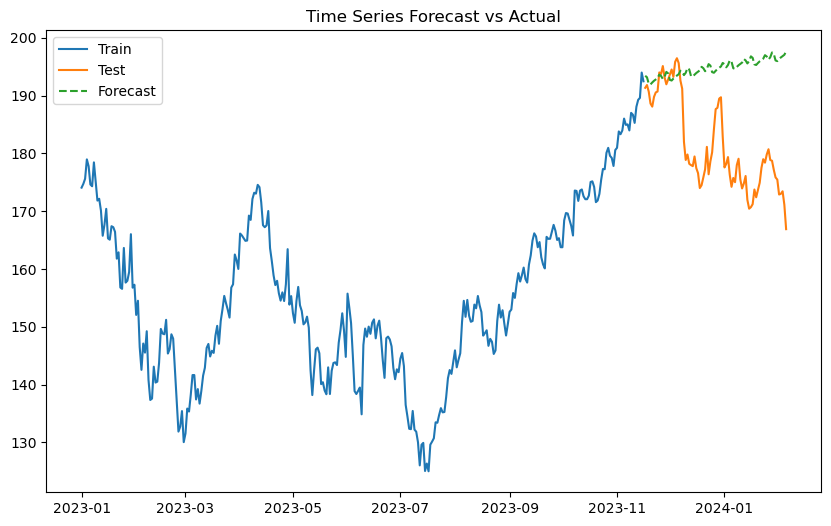

In [79]:
# Step 5: Plot and Compare Predictions

import matplotlib.pyplot as plt

# Plot the forecast against the actual values
plt.figure(figsize=(10, 6))
plt.plot(train.index, train['x'], label="Train")
plt.plot(test.index, test['x'], label="Test")
plt.plot(test.index, forecast, label="Forecast", linestyle='--')
plt.legend(loc="best")
plt.title('Time Series Forecast vs Actual')
plt.show()

In [81]:
# Step 6: Evaluate the Model

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate the error metrics
mse = mean_squared_error(test['x'], forecast)
mae = mean_absolute_error(test['x'], forecast)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')

Mean Squared Error: 258.901696359383
Mean Absolute Error: 13.70881686239298
